# scVI evaluation plots for different histogram bin counts (rebuttal)

Mirrors `generate_plots_scvi_models_different_alpha_rebuttal.ipynb`, but varies **bins** instead of **alpha**.

- **AR** (all bin counts, including 100): `rebuttal_round2/result_9_8_26/test/`
- **Standard / Naive** only: manuscript baseline dirs (`…-20250409-manuscript-version`), treated as `bins=100`

Plots: lineplots vs `Atlas_cell_count`, `hue=ARtype`, `style=bins`.

In [21]:
from pathlib import Path
import os
import pickle
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eval_scripts" else NOTEBOOK_DIR

BIN_RESULTS_ROOT = Path(
    "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/"
    "rebuttal_round2/result_9_8_26/test"
)
CLASS_BIN_DIR = BIN_RESULTS_ROOT / "scVI-classification-evals-bins"
RECON_BIN_DIR = BIN_RESULTS_ROOT / "scVI-reconstruction-evals-bins"

CLASS_BASELINE_DIR = (
    REPO_ROOT / "result/test/sctab/zeinab-classification-evals-20250409-manuscript-version"
)
RECON_BASELINE_DIR = (
    REPO_ROOT / "result/test/sctab/zeinab-reconstruction-evals-20250409-manuscript-version"
)

FIG_DIR = Path(
    "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/"
    "rebuttal_round2/figures/evals_for_different_bins"
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_BINS = 100
DEFAULT_ALPHA = 0.0001
SEEDS = [42, 43, 44, 45, 46]
PALETTE = {"Standard": "darkgray", "AR": "brown"}

print("Classification (bins):", CLASS_BIN_DIR)
print("Reconstruction (bins):", RECON_BIN_DIR)
print("Figures:", FIG_DIR)

Classification (bins): /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/result_9_8_26/test/scVI-classification-evals-bins
Reconstruction (bins): /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/result_9_8_26/test/scVI-reconstruction-evals-bins
Figures: /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins


## Classification metrics

In [22]:
CLASS_COLS = [
    "accuracy", "precision", "recall", "micro_f1", "macro_f1",
    "seed", "dataset", "ARtype", "latent_dim", "Atlas_cell_count", "alpha", "bins",
]


def load_classification_csvs(csv_dir: Path, default_bins=None) -> pd.DataFrame:
    rows = []
    for file in sorted(csv_dir.glob("*.csv")):
        df_temp = pd.read_csv(file)
        if "bins" not in df_temp.columns:
            if default_bins is None:
                raise ValueError(f"No bins column and no default_bins for {file.name}")
            df_temp["bins"] = default_bins
        if "alpha" not in df_temp.columns:
            df_temp["alpha"] = DEFAULT_ALPHA
        keep = [c for c in CLASS_COLS if c in df_temp.columns]
        rows.append(df_temp[keep])
    if not rows:
        return pd.DataFrame(columns=CLASS_COLS)
    out = pd.concat(rows, ignore_index=True)
    return out.drop_duplicates()


# AR: all bins from result_9_8_26/test only.
df_class_ar = load_classification_csvs(CLASS_BIN_DIR)
df_class_ar = df_class_ar[df_class_ar["ARtype"].isin(["T", "AR", True, "True"])].copy()
df_class_ar["ARtype"] = "T"

# Standard/Naive: manuscript baseline only (default bins=100).
df_class_std = load_classification_csvs(CLASS_BASELINE_DIR, default_bins=DEFAULT_BINS)
df_class_std = df_class_std[df_class_std["ARtype"].isin(["F", "Standard", "Naive", False, "False"])].copy()
df_class_std["ARtype"] = "F"

df_class = pd.concat([df_class_ar, df_class_std], ignore_index=True).drop_duplicates()

df_class["seed"] = df_class["seed"].astype(int)
df_class["Atlas_cell_count"] = df_class["Atlas_cell_count"].astype(int)
df_class["bins"] = df_class["bins"].astype(int)
df_class["alpha"] = df_class["alpha"].astype(float)
df_class = df_class[df_class["seed"].isin(SEEDS)].copy()
df_class = df_class[df_class["alpha"] == DEFAULT_ALPHA].copy()

print("rows:", len(df_class))
print("bins:", sorted(df_class["bins"].unique()))
print("ARtype:", df_class["ARtype"].value_counts().to_dict())
print("sources: AR from", CLASS_BIN_DIR.name, "| Standard from", CLASS_BASELINE_DIR.name)
print("coverage (dataset, bins, ARtype):")
print(df_class.groupby(["dataset", "bins", "ARtype"]).size())
df_class.head()

rows: 630
bins: [50, 80, 100, 120, 150]
ARtype: {'T': 525, 'F': 105}
sources: AR from scVI-classification-evals-bins | Standard from zeinab-classification-evals-20250409-manuscript-version
coverage (dataset, bins, ARtype):
dataset  bins  ARtype
Heart    50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
Kidney   50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
Neurons  50    T         35
         80    T         35
         100   F         35
               T         35
         120   T         35
         150   T         35
dtype: int64


,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,alpha,bins
0,0.729738,0.698935,0.513686,0.729738,0.551972,42,Heart,T,64,0,0.0001,100
1,0.725906,0.695968,0.508889,0.725906,0.539906,42,Heart,T,64,0,0.0001,120
2,0.727233,0.733347,0.500957,0.727233,0.535229,42,Heart,T,64,0,0.0001,150
3,0.727085,0.699688,0.524524,0.727085,0.561656,42,Heart,T,64,0,0.0001,50
4,0.735043,0.679682,0.511015,0.735043,0.546028,42,Heart,T,64,0,0.0001,80


In [23]:
df_class = df_class.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "micro_f1": "Micro F1 Score",
    "macro_f1": "Macro F1 Score",
    "bins": "Bins",
})
df_class["ARtype"] = df_class["ARtype"].replace({"T": "AR", "F": "Standard"})

metrics = ["Accuracy", "Precision", "Recall", "Micro F1 Score", "Macro F1 Score"]
plot_df_list = []
for _, row in df_class.iterrows():
    for metric in metrics:
        plot_df_list.append({
            "dataset": row["dataset"],
            "metric": metric,
            "value": row[metric],
            "ARtype": row["ARtype"],
            "Atlas_cell_count": row["Atlas_cell_count"],
            "Bins": row["Bins"],
            "seed": row["seed"],
        })

plot_df = pd.DataFrame(plot_df_list)
plot_df = plot_df.sort_values(by=["Bins", "Atlas_cell_count", "dataset", "metric"])
plot_df.head()

,dataset,metric,value,ARtype,Atlas_cell_count,Bins,seed
15,Heart,Accuracy,0.727085,AR,0,50,42
190,Heart,Accuracy,0.732685,AR,0,50,43
365,Heart,Accuracy,0.728559,AR,0,50,44
540,Heart,Accuracy,0.742706,AR,0,50,45
715,Heart,Accuracy,0.745800,AR,0,50,46


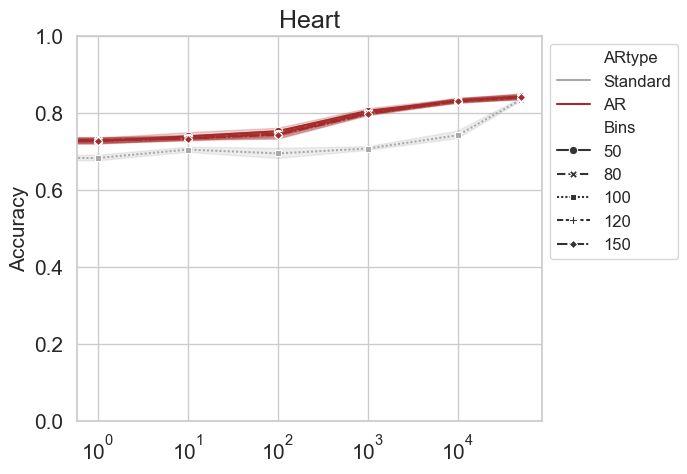

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Accuracy.png


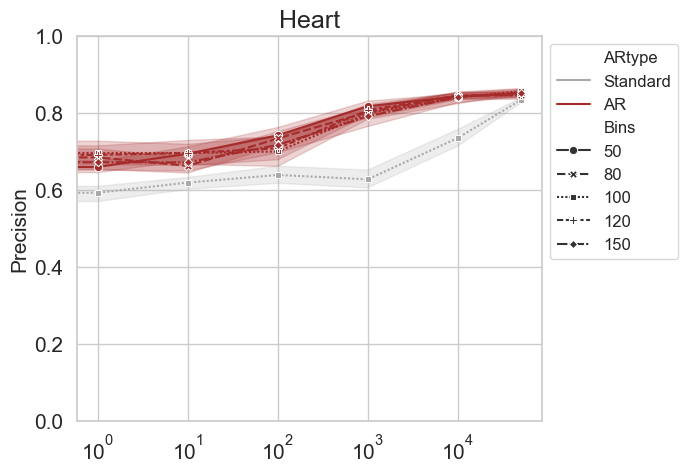

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Precision.png


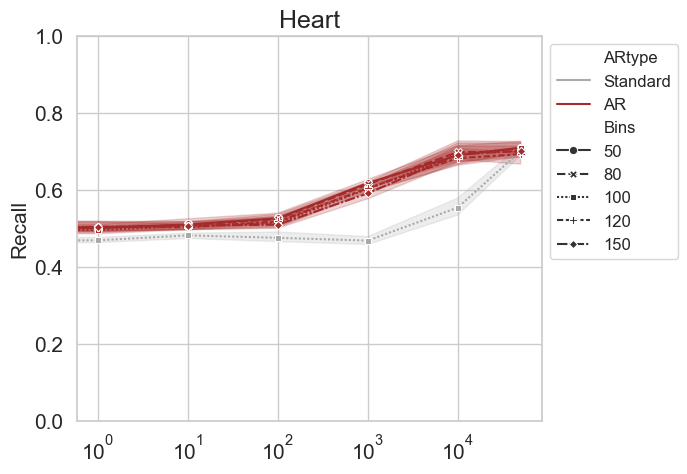

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Recall.png


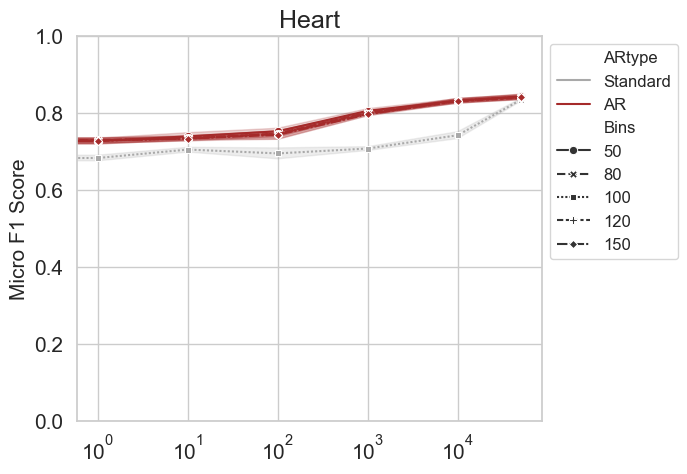

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Micro_F1_Score.png


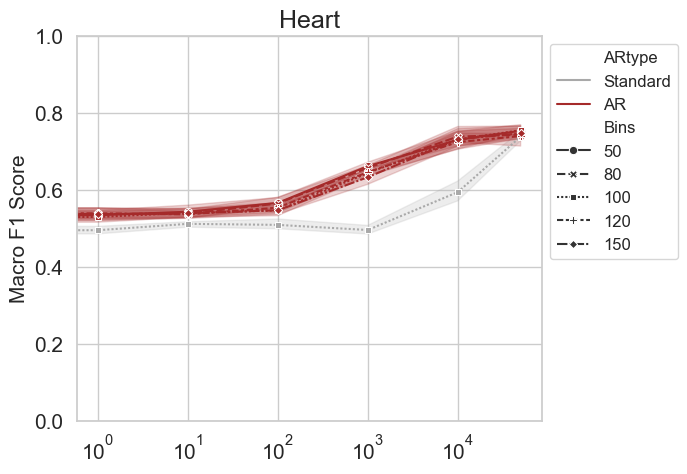

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Heart_Macro_F1_Score.png


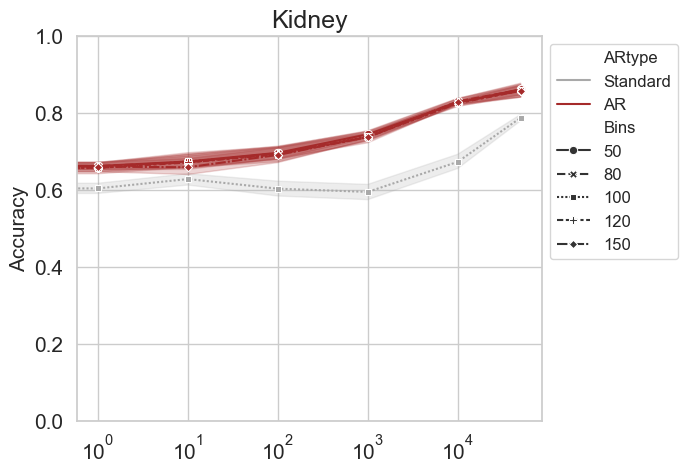

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Accuracy.png


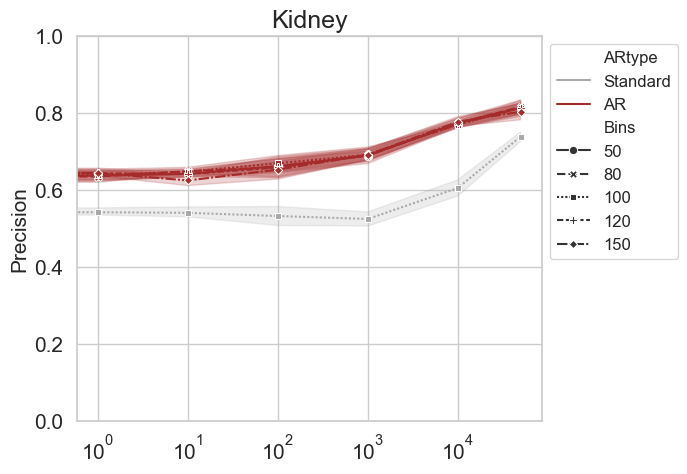

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Precision.png


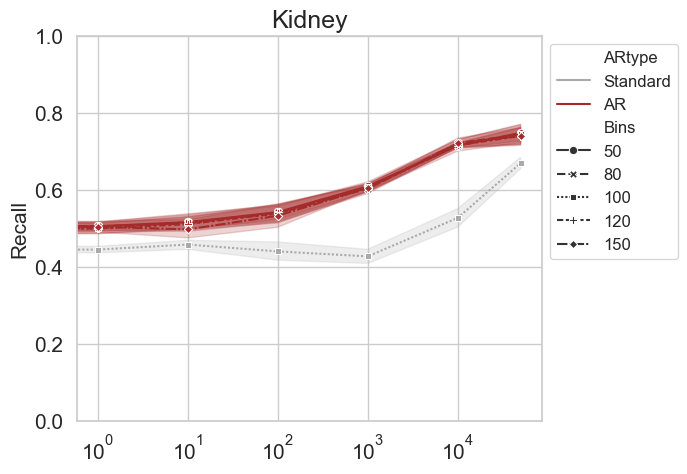

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Recall.png


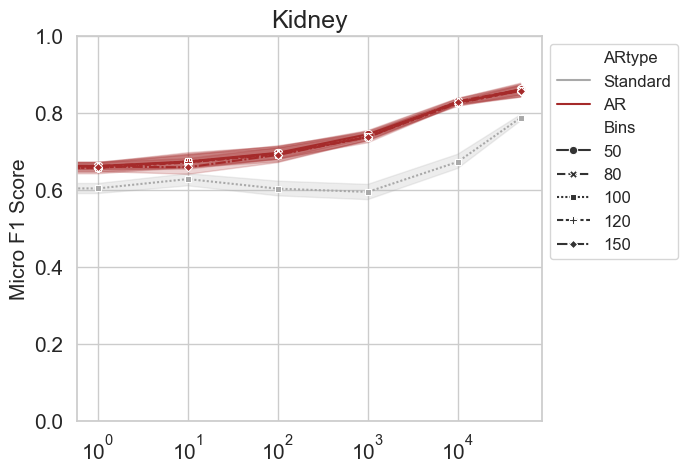

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Micro_F1_Score.png


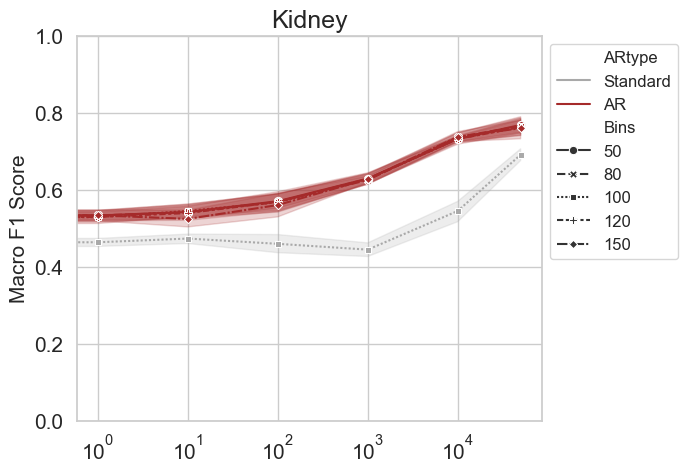

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Kidney_Macro_F1_Score.png


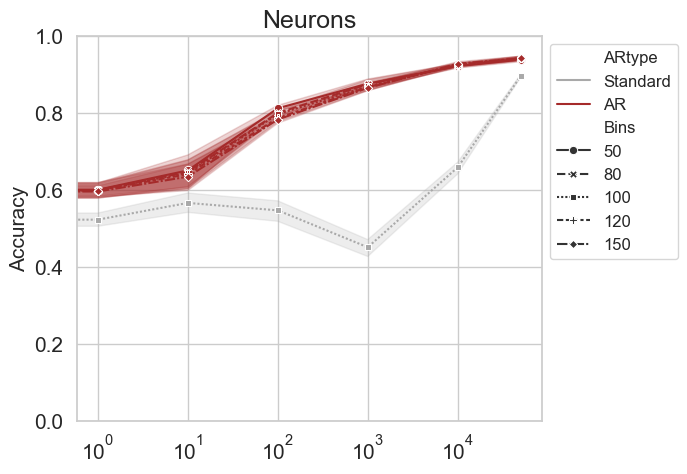

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Accuracy.png


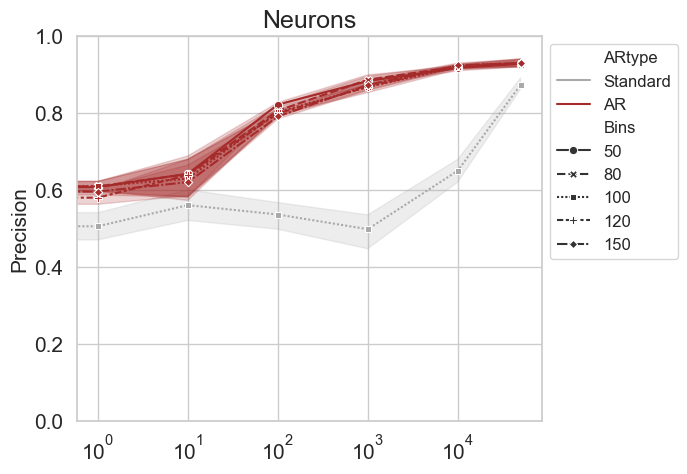

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Precision.png


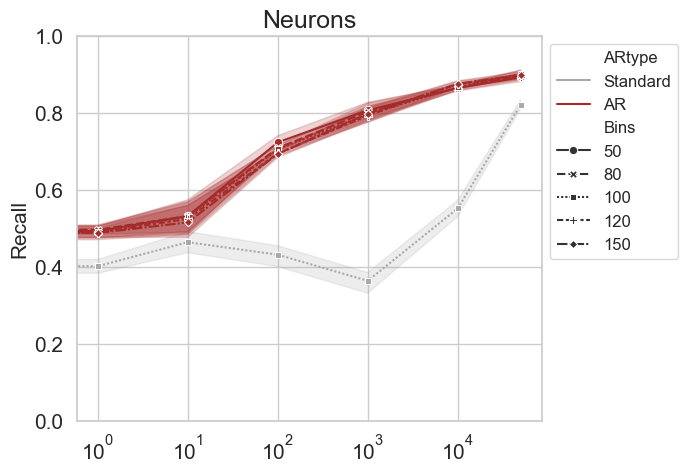

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Recall.png


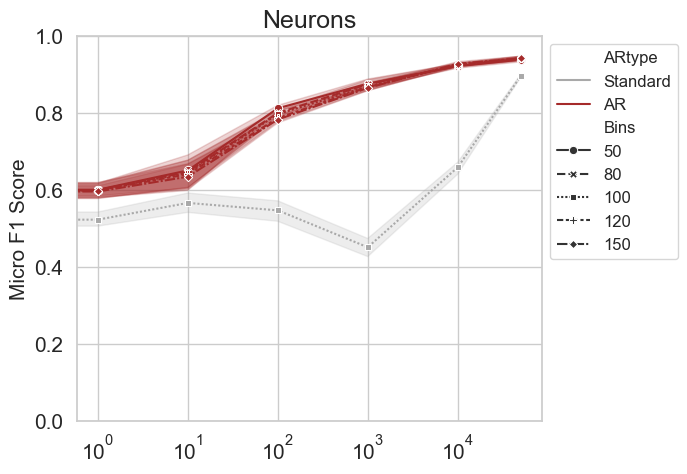

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Micro_F1_Score.png


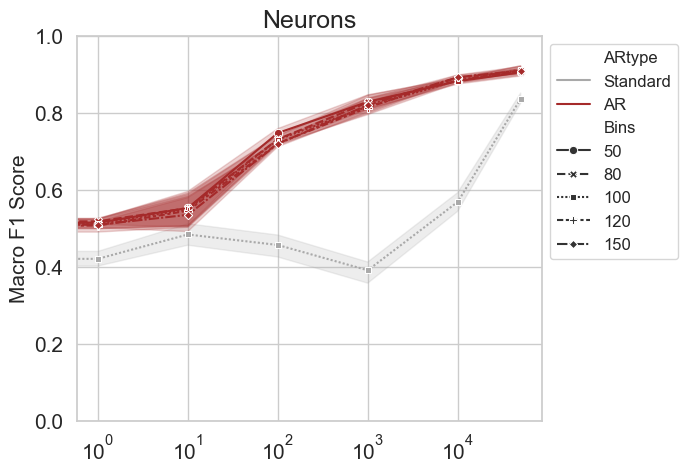

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/classification_Neurons_Macro_F1_Score.png


In [24]:
for dataset in sorted(plot_df["dataset"].unique()):
    for metric in metrics:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        g = sns.lineplot(
            data=plot_df[(plot_df["dataset"] == dataset) & (plot_df["metric"] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="ARtype",
            style="Bins",
            palette=PALETTE,
            hue_order=["Standard", "AR"],
            markers=True,
            dashes=True,
            ax=ax,
        )
        g.set_xlabel("")
        g.set_ylabel(metric, fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis="both", which="major", labelsize=15)
        g.legend(loc="upper left", fontsize=12, bbox_to_anchor=(1, 1))
        g.set(ylim=(0, 1))
        g.set_xscale("log", base=10)
        out = FIG_DIR / f"classification_{dataset}_{metric.replace(' ', '_')}.png"
        plt.savefig(out, dpi=600, bbox_inches="tight")
        plt.show()
        print("saved", out)

## Reconstruction metrics

In [25]:
RECON_NAME_RE = re.compile(
    r"Reconstruction_seed_(?P<seed>\d+)_ARtype_(?P<ARtype>[TF])_"
    r".*_Atlas_cell_count_(?P<atlas>\d+)_"
    r"(?:alpha_(?P<alpha>[0-9.eE+-]+)_)?"
    r"(?:bins_(?P<bins>\d+)_)?"
)


class _NumpyCompatUnpickler(pickle.Unpickler):
    """Load pickles saved with NumPy 2.x (`numpy._core`) under NumPy 1.x."""

    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = "numpy.core" + module[len("numpy._core"):]
        return super().find_class(module, name)


def load_pickle(path: Path):
    with open(path, "rb") as f:
        return _NumpyCompatUnpickler(f).load()


def normalize_recon_dataset(name: str) -> str:
    lower = name.lower()
    if "heart" in lower:
        return "Heart"
    if "kidney" in lower:
        return "Kidney"
    if "neuron" in lower:
        return "Neurons"
    return name


def load_reconstruction_pickles(pkl_dir: Path, default_bins=None, default_alpha=DEFAULT_ALPHA) -> pd.DataFrame:
    records = []
    for file in sorted(pkl_dir.glob("*.pkl")):
        if "Reconstruction_seed_" not in file.name:
            continue
        m = RECON_NAME_RE.search(file.name)
        if m is None:
            print("skip (unparsed):", file.name)
            continue
        seed = int(m.group("seed"))
        artype = m.group("ARtype")
        atlas = int(m.group("atlas"))
        alpha = float(m.group("alpha")) if m.group("alpha") else default_alpha
        bins = int(m.group("bins")) if m.group("bins") else default_bins
        if bins is None:
            raise ValueError(f"Could not determine bins for {file.name}")

        data = load_pickle(file)
        for key, test_df in data.items():
            records.append({
                "dataset": normalize_recon_dataset(key),
                "metric": "correlation",
                "value": float(test_df["correlation"].mean()),
                "ARtype": artype,
                "Atlas_cell_count": atlas,
                "seed": seed,
                "Bins": bins,
                "alpha": alpha,
            })
            records.append({
                "dataset": normalize_recon_dataset(key),
                "metric": "r2",
                "value": float(test_df["r2"].mean()),
                "ARtype": artype,
                "Atlas_cell_count": atlas,
                "seed": seed,
                "Bins": bins,
                "alpha": alpha,
            })
    return pd.DataFrame.from_records(records)


df_recon_ar = load_reconstruction_pickles(RECON_BIN_DIR)
df_recon_ar = df_recon_ar[df_recon_ar["ARtype"].isin(["T", "AR", True, "True"])].copy()
df_recon_ar["ARtype"] = "T"

df_recon_std = load_reconstruction_pickles(RECON_BASELINE_DIR, default_bins=DEFAULT_BINS)
df_recon_std = df_recon_std[df_recon_std["ARtype"].isin(["F", "Standard", "Naive", False, "False"])].copy()
df_recon_std["ARtype"] = "F"

df_recon = pd.concat([df_recon_ar, df_recon_std], ignore_index=True).drop_duplicates()

df_recon = df_recon[df_recon["seed"].isin(SEEDS)].copy()
df_recon = df_recon[df_recon["alpha"] == DEFAULT_ALPHA].copy()
df_recon["ARtype"] = df_recon["ARtype"].replace({"T": "AR", "F": "Standard"})
df_recon["Atlas_cell_count"] = df_recon["Atlas_cell_count"].astype(int)
df_recon["Bins"] = df_recon["Bins"].astype(int)
df_recon = df_recon.sort_values(by=["Bins", "Atlas_cell_count", "dataset", "metric"])

print("rows:", len(df_recon))
print("bins:", sorted(df_recon["Bins"].unique()))
print("ARtype:", df_recon["ARtype"].value_counts().to_dict())
print("sources: AR from", RECON_BIN_DIR.name, "| Standard from", RECON_BASELINE_DIR.name)
print("coverage (dataset, Bins, ARtype) for correlation:")
print(
    df_recon[df_recon["metric"] == "correlation"]
    .groupby(["dataset", "Bins", "ARtype"])
    .size()
)
df_recon.head()

rows: 1260
bins: [50, 80, 100, 120, 150]
ARtype: {'AR': 1050, 'Standard': 210}
sources: AR from scVI-reconstruction-evals-bins | Standard from zeinab-reconstruction-evals-20250409-manuscript-version
coverage (dataset, Bins, ARtype) for correlation:
dataset  Bins  ARtype  
Heart    50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
Kidney   50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
Neurons  50    AR          35
         80    AR          35
         100   AR          35
               Standard    35
         120   AR          35
         150   AR          35
dtype: int64


,dataset,metric,value,ARtype,Atlas_cell_count,seed,Bins,alpha
18,Heart,correlation,0.218587,AR,0,42,50,0.0001
228,Heart,correlation,0.225198,AR,0,43,50,0.0001
438,Heart,correlation,0.224340,AR,0,44,50,0.0001
648,Heart,correlation,0.212142,AR,0,45,50,0.0001
858,Heart,correlation,0.226576,AR,0,46,50,0.0001


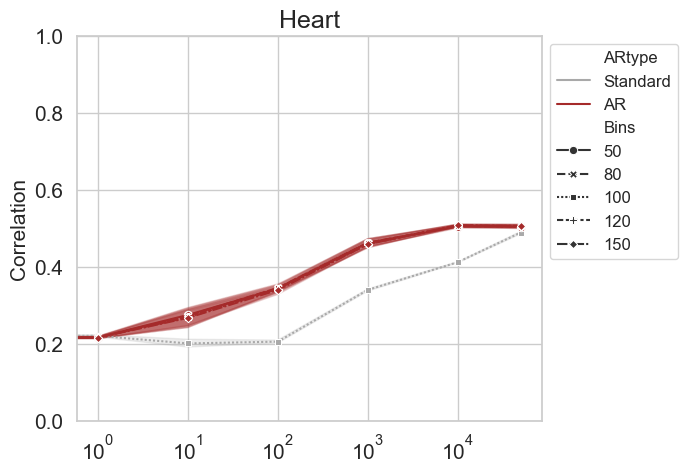

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Heart_correlation.png


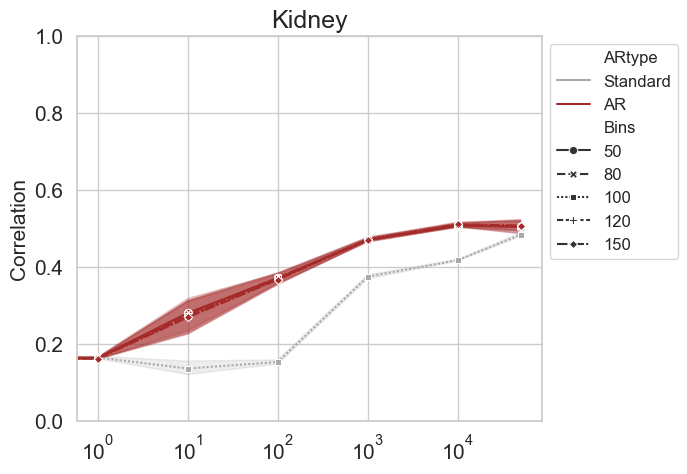

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Kidney_correlation.png


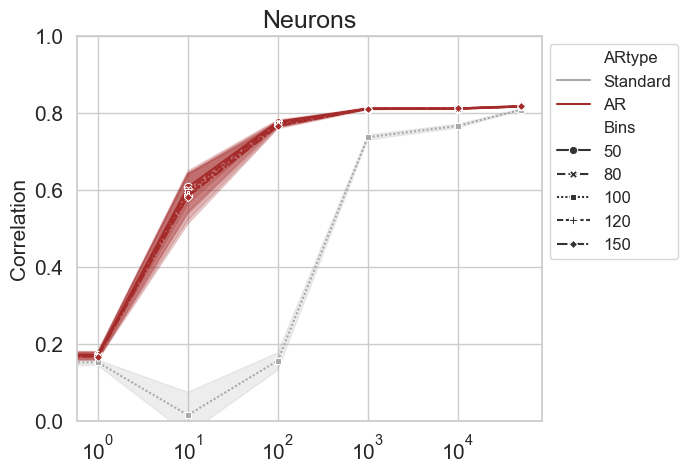

saved /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal_round2/figures/evals_for_different_bins/reconstruction_Neurons_correlation.png


In [26]:
for dataset in sorted(df_recon["dataset"].unique()):
    for metric in ["correlation"]:
        fig, ax = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        g = sns.lineplot(
            data=df_recon[(df_recon["dataset"] == dataset) & (df_recon["metric"] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="ARtype",
            style="Bins",
            palette=PALETTE,
            hue_order=["Standard", "AR"],
            markers=True,
            dashes=True,
            ax=ax,
        )
        g.set_xlabel("")
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis="both", which="major", labelsize=15)
        g.set_xscale("log", base=10)
        g.legend(loc="upper left", fontsize=12, bbox_to_anchor=(1, 1))
        g.set(ylim=(0, 1))
        out = FIG_DIR / f"reconstruction_{dataset}_{metric}.png"
        plt.savefig(out, dpi=600, bbox_inches="tight")
        plt.show()
        print("saved", out)

## Notes

- **AR** for all bin counts (including 100) is loaded only from `result_9_8_26/test/` (`scVI-*-evals-bins`).
- **Standard / Naive** is loaded only from the manuscript baseline dirs (assigned `bins=100`).
- Old baseline AR (`ARtype=T`) is intentionally **not** used.
- Reconstruction pickles already contain Heart/Kidney/Neurons in one file per (seed, AR, atlas, bins).
- Some reconstruction pickles were written with NumPy 2; the notebook remaps `numpy._core` → `numpy.core` when loading.
